# Emotions classification from Images

### Import libraries and modules

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import zipfile
import tensorflow as tf

from google.colab.patches import cv2_imshow
from google.colab import drive

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, BatchNormalization

from keras.models import save_model

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

### Loading the images

In [2]:
drive.mount('/content/drive')
# Define paths for images, classifiers and models
image_folder_path = '/content/drive/My Drive/Colab Notebooks/Computer Vision Masterclass_Udemy/Training_Material/'

Mounted at /content/drive


In [3]:
path = image_folder_path +'/Datasets/fer_images.zip'
zip_object = zipfile.ZipFile(file=path, mode='r')
zip_object.extractall('./')
zip_object.close()

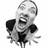

In [4]:
tf.keras.preprocessing.image.load_img('/content/fer2013/train/Angry/1003.jpg')

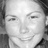

In [5]:
image = tf.keras.preprocessing.image.load_img('/content/fer2013/train/Happy/1.jpg')
image

### Train and Test dataset

In [ ]:
# Create an instance of the ImageDataGenerator class for data augmentation, which will generate batches of tensor image data with real-time data augmentation. 
# The data will be looped over (in batches) indefinitely. The ImageDataGenerator class allows you to configure random transformations and normalization operations to be done on your image data during training. This is useful for training deep learning models as it helps to prevent overfitting and improve generalization. 
# Also, it can be used to rescale pixel values, apply random transformations like rotation, flipping, shifting, and zooming to the images in the training dataset. This helps to create a more diverse set of training examples and improve the model's ability to generalize to new data. 
training_generator = ImageDataGenerator(
    rescale=1./255,         # Rescale the pixel values 
    rotation_range=7,       # Randomly rotate images in the range (degrees, 0 to 180)
    horizontal_flip=True,   # Randomly flip inputs horizontally
    width_shift_range=0.2,  # Randomly translate images horizontally (fraction of total width)
    zoom_range=0.2          # Randomly zoom images
)

# Train dataset is created using the flow_from_directory method of the ImageDataGenerator class. This method takes the path to the directory containing the training images, along with other parameters such as target size, batch size, class mode, and shuffle. 
# The target size specifies the dimensions to which all images will be resized, while the batch size determines how many images will be processed in each batch. The class mode specifies how the labels are generated (in this case, categorical), and shuffle indicates whether to shuffle the data after each epoch.
train_dataset = training_generator.flow_from_directory(
    '/content/fer2013/train',   # Path to the directory containing the training images
    target_size = (48, 48),     # Resize all images to 48x48 pixels
    batch_size = 16,            # Number of images to be yielded from the generator per batch
    class_mode = 'categorical', # Specify the type of label arrays that are returned: 'categorical' means 2D one-hot encoded labels
    shuffle = True              # Whether to shuffle the data after each epoch
)

Found 28709 images belonging to 7 classes.


In [5]:
train_dataset.classes

array([0, 0, 0, ..., 6, 6, 6], dtype=int32)

In [ ]:
# Get the unique classes and their counts in the training dataset using numpy's unique function. This will return an array of unique class labels and an array of their corresponding counts.
np.unique(train_dataset.classes, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6], dtype=int32),
 array([3995,  436, 4097, 7215, 4965, 4830, 3171]))

In [ ]:
# Get the class indices mapping from the training dataset. This will return a dictionary where the keys are the class labels and the values are the corresponding integer indices assigned to each class.
train_dataset.class_indices

{'Angry': 0,
 'Disgust': 1,
 'Fear': 2,
 'Happy': 3,
 'Neutral': 4,
 'Sad': 5,
 'Surprise': 6}

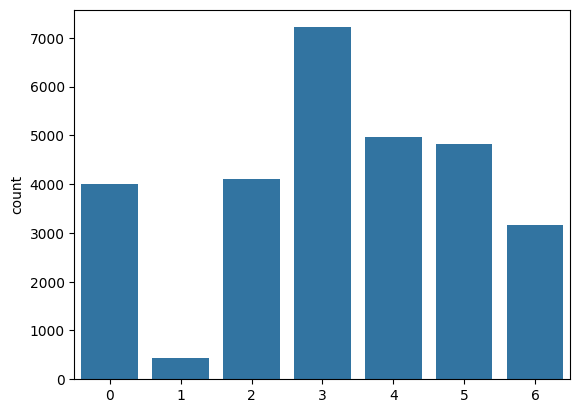

In [ ]:
# Visualize the distribution of classes in the training dataset using a count plot. This will help to understand if the dataset is balanced or imbalanced across different emotion classes.
sns.countplot(x = train_dataset.classes);

In [ ]:
# Create an instance of the ImageDataGenerator class for the test dataset. This generator will only rescale the pixel values of the images in the test dataset, without applying any data augmentation techniques. This is because we want to evaluate the model's performance on unaltered test data.
test_generator = ImageDataGenerator(rescale=1./255)

# Create the test dataset using the flow_from_directory method of the ImageDataGenerator class. This method takes the path to the directory containing the test images, along with other parameters such as target size, batch size, class mode, and shuffle.
test_dataset = test_generator.flow_from_directory(
    '/content/fer2013/validation', 
    target_size = (48, 48), 
    batch_size = 1, 
    class_mode = 'categorical', 
    shuffle = False
)

Found 3589 images belonging to 7 classes.


### Building and training the convolutional neural network

In [12]:
2*2*2*32

256

In [ ]:
# Based on: https://github.com/rajeevratan84/DeepLearningCV/blob/master/18.2%20Building%20an%20Emotion%20Detector%20with%20LittleVGG.ipynb
# Padding: https://www.pico.net/kb/what-is-the-difference-between-same-and-valid-padding-in-tf-nn-max-pool-of-tensorflow
# BatchNormalization: https://keras.io/api/layers/normalization_layers/batch_normalization/
# Dropout: https://jmlr.org/papers/volume15/srivastava14a.old/srivastava14a.pdf

num_detectors = 32
num_classes = 7
width, height = 48, 48
epochs = 70

network = Sequential()

# Add convolutional layers with ReLU activation, batch normalization, max pooling, and dropout to the network. The first layer specifies the input shape of the images (48x48 pixels with 3 color channels). The number of detectors (filters) in each convolutional layer is doubled after each max pooling layer to capture more complex features as the network goes deeper. Dropout is applied after each max pooling layer to prevent overfitting by randomly dropping out a fraction of the neurons during training.
# The final layers of the network consist of fully connected (dense) layers with ReLU activation, batch normalization, and dropout, followed by a softmax output layer that produces a probability distribution over the 7 emotion classes. The network summary is printed to show the architecture and number of parameters in each layer.

network.add(Conv2D(num_detectors, (3,3), activation='relu', padding = 'same', input_shape = (width, height, 3)))
network.add(BatchNormalization())
network.add(Conv2D(num_detectors, (3,3), activation='relu', padding = 'same'))
network.add(BatchNormalization())
network.add(MaxPooling2D(pool_size=(2,2)))
network.add(Dropout(0.2)) # Dropping out 20% of the neurons to prevent overfitting

network.add(Conv2D(2*num_detectors, (3,3), activation='relu', padding = 'same'))
network.add(BatchNormalization())
network.add(Conv2D(2*num_detectors, (3,3), activation='relu', padding = 'same'))
network.add(BatchNormalization())
network.add(MaxPooling2D(pool_size=(2,2)))
network.add(Dropout(0.2))

network.add(Conv2D(2*2*num_detectors, (3,3), activation='relu', padding = 'same'))
network.add(BatchNormalization())
network.add(Conv2D(2*2*num_detectors, (3,3), activation='relu', padding = 'same'))
network.add(BatchNormalization())
network.add(MaxPooling2D(pool_size=(2,2)))
network.add(Dropout(0.2))

network.add(Conv2D(2*2*2*num_detectors, (3,3), activation='relu', padding = 'same'))
network.add(BatchNormalization())
network.add(Conv2D(2*2*2*num_detectors, (3,3), activation='relu', padding = 'same'))
network.add(BatchNormalization())
network.add(MaxPooling2D(pool_size=(2,2)))
network.add(Dropout(0.2))

# Flatten the output of the convolutional layers to prepare it for the fully connected (dense) layers. The Flatten layer converts the 2D feature maps into a 1D feature vector, which can then be fed into the dense layers for classification. 
# This is an important step in the architecture of a convolutional neural network, as it allows the model to learn complex patterns and relationships in the data by combining the features extracted by the convolutional layers. 
network.add(Flatten())

# Add fully connected (dense) layers with ReLU activation, batch normalization, and dropout to the network. The first dense layer has twice the number of detectors as the last convolutional layer, while the second dense layer has the same number of detectors as the last convolutional layer. Dropout is applied after each dense layer to prevent overfitting by randomly dropping out a fraction of the neurons during training.
network.add(Dense(2 * num_detectors, activation='relu'))
network.add(BatchNormalization())
network.add(Dropout(0.2))

network.add(Dense(2 * num_detectors, activation='relu'))
network.add(BatchNormalization())
network.add(Dropout(0.2))

# Add the final output layer with softmax activation to the network. The number of neurons in this layer corresponds to the number of emotion classes (7 in this case). The softmax activation function is used to produce a probability distribution over the classes, allowing the model to output the predicted probabilities for each emotion class.
network.add(Dense(num_classes, activation='softmax'))

# Print the summary of the network architecture, which includes information about each layer, the output shape, and the number of parameters in the model. This summary provides a clear overview of the model's structure and complexity, helping to understand how the data flows through the network and how many learnable parameters are present in each layer.
print(network.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,328,743 (5.07 MB)

 Trainable params: 1,326,567 (5.06 MB)

 Non-trainable params: 2,176 (8.50 KB)

None


In [ ]:
# Compile the network with the Adam optimizer, categorical crossentropy loss function, and accuracy as the evaluation metric. The Adam optimizer is an adaptive learning rate optimization algorithm that combines the advantages of two other popular optimizers: AdaGrad and RMSProp. Categorical crossentropy is used as the loss function for multi-class classification problems, where the model outputs a probability distribution over multiple classes. Accuracy is used as a metric to evaluate the performance of the model during training and testing.
network.compile(
    optimizer='Adam', 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

In [12]:
# Train the network using the fit method, which takes the training dataset and the number of epochs as input. The model will be trained for the specified number of epochs, during which it will learn to classify the images in the training dataset into one of the 7 emotion classes. The fit method will return a history object containing information about the training process, such as loss and accuracy metrics for each epoch.  
network.fit(train_dataset, epochs=epochs)

Epoch 1/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 77s 33ms/step - accuracy: 0.2243 - loss: 1.9165
Epoch 2/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 49s 27ms/step - accuracy: 0.3136 - loss: 1.7050
Epoch 3/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 49s 27ms/step - accuracy: 0.4071 - loss: 1.5245
Epoch 4/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 49s 27ms/step - accuracy: 0.4601 - loss: 1.4128
Epoch 5/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 49s 27ms/step - accuracy: 0.4932 - loss: 1.3348
Epoch 6/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 49s 28ms/step - accuracy: 0.5153 - loss: 1.2820
Epoch 7/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 48s 27ms/step - accuracy: 0.5333 - loss: 1.2464
Epoch 8/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 48s 27ms/step - accuracy: 0.5491 - loss: 1.2081
Epoch 9/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 50s 28ms/step - accuracy: 0.5597 - loss: 1.1820
Epoch 10/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 48s 27ms/step - accuracy: 0.5656 - loss: 1.1681
Epoch 11/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.5739 - loss: 1.1445
Epoch 12

### Saving and loading the model

In [13]:
# Save the trained model to a file named 'network_emotions.h5' using the save_model function from Keras. This allows you to save the entire model architecture, weights, and optimizer state, so that you can later load the model and use it for inference or further training without having to retrain it from scratch.
model_json = network.to_json()
with open('network_emotions.json','w') as json_file:
  json_file.write(model_json)

In [ ]:
# Save the model weights to a file named 'weights_emotions.hdf5' using the save_model function from Keras. This allows you to save only the weights of the trained model, which can be useful if you want to load the weights into a different model architecture or if you want to save storage space by not saving the entire model.
network_saved = save_model(network, image_folder_path + 'Weights/weights_emotions.hdf5')

In [ ]:
# Load the saved model architecture from the 'network_emotions.json' file and create a new model instance using the model_from_json function from Keras. The custom_objects parameter is used to specify any custom layers or objects that may be present in the model architecture. In this case, we are specifying that the Sequential class should be used for the model.
with open(image_folder_path + 'Weights/network_emotions.json', 'r') as json_file:
  json_saved_model = json_file.read()
json_saved_model

'{"class_name": "Sequential", "config": {"name": "sequential_1", "layers": [{"class_name": "InputLayer", "config": {"batch_input_shape": [null, 48, 48, 3], "dtype": "float32", "sparse": false, "ragged": false, "name": "conv2d_8_input"}}, {"class_name": "Conv2D", "config": {"name": "conv2d_8", "trainable": true, "batch_input_shape": [null, 48, 48, 3], "dtype": "float32", "filters": 32, "kernel_size": [3, 3], "strides": [1, 1], "padding": "same", "data_format": "channels_last", "dilation_rate": [1, 1], "groups": 1, "activation": "relu", "use_bias": true, "kernel_initializer": {"class_name": "GlorotUniform", "config": {"seed": null}}, "bias_initializer": {"class_name": "Zeros", "config": {}}, "kernel_regularizer": null, "bias_regularizer": null, "activity_regularizer": null, "kernel_constraint": null, "bias_constraint": null}}, {"class_name": "BatchNormalization", "config": {"name": "batch_normalization_8", "trainable": true, "dtype": "float32", "axis": [3], "momentum": 0.99, "epsilon": 0

In [ ]:
# Load the model architecture and weights into a new model instance, compile it with the same loss function, optimizer, and metrics as the original model. This allows you to use the loaded model for inference or further training without having to retrain it from scratch.
network_loaded = tf.keras.models.model_from_json(json_saved_model, custom_objects={'Sequential': tf.keras.Sequential})
network_loaded.load_weights(image_folder_path + 'Weights/weights_emotions.hdf5')
network_loaded.compile(loss = 'categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [27]:
network_loaded.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,328,743 (5.07 MB)

 Trainable params: 1,326,567 (5.06 MB)

 Non-trainable params: 2,176 (8.50 KB)

### Evaluate neural network

In [28]:
# Evaluate the loaded model on the test dataset to assess its performance. The evaluate method computes the loss and accuracy metrics for the model on the provided test dataset, allowing you to see how well the model generalizes to unseen data. 
network_loaded.evaluate(test_dataset)

3589/3589 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.5784 - loss: 1.4131


[1.413077473640442, 0.5784341096878052]

In [29]:
# Generate predictions for the test dataset using the loaded model. The predict method takes the test dataset as input and returns the predicted probabilities for each class for each image in the test dataset. These predictions can then be used to evaluate the model's performance or to make decisions based on the predicted classes.
predictions = network_loaded.predict(test_dataset)
predictions

3589/3589 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step


array([[3.3628789e-01, 1.1390010e-02, 2.0156297e-01, ..., 2.3775484e-01,
        2.1008971e-01, 3.5271296e-04],
       [9.4713181e-01, 4.7775754e-04, 4.4847883e-02, ..., 3.5856685e-04,
        5.1243120e-04, 3.6813263e-03],
       [9.4589049e-01, 1.0015544e-03, 2.3174427e-02, ..., 4.3882066e-03,
        2.1867650e-02, 1.8053727e-04],
       ...,
       [1.4794674e-03, 2.8215414e-05, 6.8992957e-02, ..., 1.1825596e-02,
        3.4777517e-03, 9.1376990e-01],
       [1.8333812e-03, 3.7640504e-05, 1.3785277e-01, ..., 1.0595969e-02,
        1.9518252e-03, 8.4772837e-01],
       [1.7477565e-02, 5.4050033e-04, 1.3035002e-01, ..., 2.9663472e-03,
        4.1076359e-03, 8.2311952e-01]], dtype=float32)

In [ ]:
# Convert the predicted probabilities into class labels by taking the index of the maximum value along the second axis (axis=1) for each prediction. This will give you the predicted class label for each image in the test dataset, which can then be compared to the true labels to evaluate the model's performance.
predictions = np.argmax(predictions, axis = 1)
predictions

array([0, 0, 0, ..., 6, 6, 6])

In [31]:
test_dataset.classes

array([0, 0, 0, ..., 6, 6, 6], dtype=int32)

In [ ]:
accuracy_score(test_dataset.classes, predictions)

0.5784341042073001

In [33]:
test_dataset.class_indices

{'Angry': 0,
 'Disgust': 1,
 'Fear': 2,
 'Happy': 3,
 'Neutral': 4,
 'Sad': 5,
 'Surprise': 6}

In [34]:
cm = confusion_matrix(test_dataset.classes, predictions)
cm

array([[321,   2,  34,  20,  63,  47,   4],
       [ 15,  32,   2,   1,   0,   5,   0],
       [ 93,   1, 214,  24,  66,  81,  49],
       [ 20,   1,  10, 781,  42,  16,   9],
       [101,   8,  73, 159, 120, 101,  64],
       [ 65,   0,  51,  32, 145, 294,   7],
       [ 13,   0,  41,  33,  13,   2, 314]])

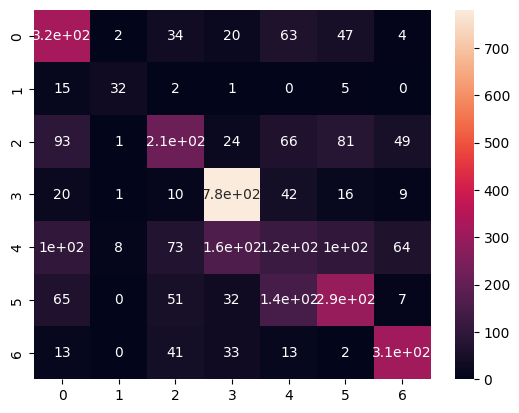

In [35]:
sns.heatmap(cm, annot=True);

In [ ]:
# Generate a classification report for the test dataset using the true labels and predicted labels. The classification report provides a summary of the precision, recall, F1-score, and support for each class in the dataset. This information can be used to evaluate the performance of the model on each emotion class and identify any areas where the model may need improvement.
print(classification_report(test_dataset.classes, predictions))

              precision    recall  f1-score   support

           0       0.51      0.65      0.57       491
           1       0.73      0.58      0.65        55
           2       0.50      0.41      0.45       528
           3       0.74      0.89      0.81       879
           4       0.27      0.19      0.22       626
           5       0.54      0.49      0.52       594
           6       0.70      0.75      0.73       416

    accuracy                           0.58      3589
   macro avg       0.57      0.57      0.56      3589
weighted avg       0.55      0.58      0.56      3589



### Classifying Emotions - one single image

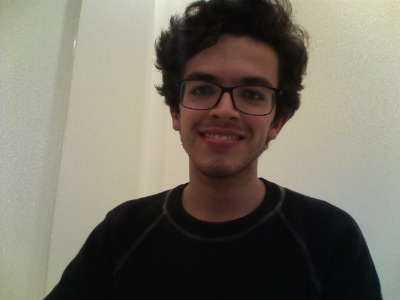

In [38]:
image = cv2.imread(image_folder_path + 'Images/gabriel.png')
cv2_imshow(image)

In [39]:
image.shape

(300, 400, 3)

In [ ]:
# Initialize the face detector using the Haar cascade classifier. The classifier is loaded from the specified XML file.
# Detect faces in the input image using the detectMultiScale method of the face detector. This method takes the input image and several parameters that control the detection process, such as scale factor, minimum neighbors, and minimum size. The method returns a list of rectangles representing the detected faces in the image.
face_detector = cv2.CascadeClassifier(image_folder_path + 'Cascades/haarcascade_frontalface_default.xml')

In [ ]:
# Make a copy of the original image to preserve it for later use. This is important because the face detection process may involve drawing rectangles or other annotations on the image, and we want to keep the original image intact for further processing or visualization.
original_image = image.copy()
faces = face_detector.detectMultiScale(original_image)
faces

array([[162,  40, 128, 128]], dtype=int32)

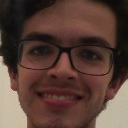

In [ ]:
# Draw rectangles around the detected faces in the original image using the coordinates returned by the detectMultiScale method. The rectangle function takes the image, the top-left corner coordinates (x, y), the bottom-right corner coordinates (x + w, y + h), the color of the rectangle (in this case, green), and the thickness of the rectangle border as input parameters. This will visually indicate where the faces have been detected in the image.
roi = image[40:40 + 128, 162:162 + 128]
cv2_imshow(roi)

In [ ]:
# Get the shape of the region of interest (ROI) extracted from the image. The shape attribute returns a tuple representing the dimensions of the ROI, which includes the height, width, and number of color channels (if applicable). This information can be useful for understanding the size and structure of the extracted face region before further processing or analysis.
roi.shape

(128, 128, 3)

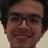

In [ ]:
# Resize the region of interest (ROI) to a fixed size of 48x48 pixels using the resize function from OpenCV. This is necessary because the model was trained on images of this size, and resizing ensures that the input to the model has the correct dimensions. After resizing, the ROI is displayed using cv2_imshow to visualize the extracted face region.
roi = cv2.resize(roi, (48, 48))
cv2_imshow(roi)

In [ ]:
# Get the shape of the region of interest (ROI) extracted from the image. The shape attribute returns a tuple representing the dimensions of the ROI, which includes the height, width, and number of color channels (if applicable). This information can be useful for understanding the size and structure of the extracted face region before further processing or analysis.
roi.shape

(48, 48, 3)

In [46]:
roi

array([[[ 28,  32,  37],
        [ 22,  28,  34],
        [ 33,  37,  42],
        ...,
        [ 12,  16,  17],
        [ 16,  21,  25],
        [ 16,  25,  30]],

       [[ 27,  31,  36],
        [ 31,  36,  41],
        [ 32,  36,  41],
        ...,
        [ 11,  16,  19],
        [ 13,  19,  24],
        [ 17,  25,  28]],

       [[ 27,  31,  36],
        [ 30,  34,  39],
        [ 26,  30,  35],
        ...,
        [ 12,  17,  20],
        [ 14,  20,  25],
        [ 20,  25,  27]],

       ...,

       [[162, 185, 197],
        [166, 188, 200],
        [166, 188, 200],
        ...,
        [162, 181, 188],
        [162, 182, 188],
        [161, 180, 187]],

       [[160, 184, 196],
        [165, 187, 199],
        [166, 188, 200],
        ...,
        [161, 180, 187],
        [162, 181, 187],
        [161, 180, 187]],

       [[160, 184, 196],
        [163, 187, 199],
        [165, 187, 199],
        ...,
        [160, 179, 186],
        [161, 180, 187],
        [162, 181, 188]]

In [ ]:
# Normalize the pixel values of the region of interest (ROI) by dividing by 255. This scales the pixel values to a range of [0, 1], which is a common preprocessing step for deep learning models. Normalizing the input data helps improve the convergence of the model during training and can lead to better performance during inference.
roi = roi / 255
roi

array([[[0.10980392, 0.1254902 , 0.14509804],
        [0.08627451, 0.10980392, 0.13333333],
        [0.12941176, 0.14509804, 0.16470588],
        ...,
        [0.04705882, 0.0627451 , 0.06666667],
        [0.0627451 , 0.08235294, 0.09803922],
        [0.0627451 , 0.09803922, 0.11764706]],

       [[0.10588235, 0.12156863, 0.14117647],
        [0.12156863, 0.14117647, 0.16078431],
        [0.1254902 , 0.14117647, 0.16078431],
        ...,
        [0.04313725, 0.0627451 , 0.0745098 ],
        [0.05098039, 0.0745098 , 0.09411765],
        [0.06666667, 0.09803922, 0.10980392]],

       [[0.10588235, 0.12156863, 0.14117647],
        [0.11764706, 0.13333333, 0.15294118],
        [0.10196078, 0.11764706, 0.1372549 ],
        ...,
        [0.04705882, 0.06666667, 0.07843137],
        [0.05490196, 0.07843137, 0.09803922],
        [0.07843137, 0.09803922, 0.10588235]],

       ...,

       [[0.63529412, 0.7254902 , 0.77254902],
        [0.65098039, 0.7372549 , 0.78431373],
        [0.65098039, 0

In [ ]:
# Get the shape of the region of interest (ROI) extracted from the image. The shape attribute returns a tuple representing the dimensions of the ROI, which includes the height, width, and number of color channels (if applicable). This information can be useful for understanding the size and structure of the extracted face region before further processing or analysis.
roi.shape

(48, 48, 3)

In [ ]:
# Expand the dimensions of the region of interest (ROI) to add a new axis at the beginning. This is necessary because the model expects input data in a specific shape, typically (batch_size, height, width, channels). By expanding the dimensions, we create a batch of size 1, allowing the model to process the single ROI image correctly.
roi = np.expand_dims(roi, axis = 0)
roi.shape

(1, 48, 48, 3)

In [ ]:
# Generate predictions for the region of interest (ROI) using the loaded model. The predict method takes the ROI as input and returns the predicted probabilities for each class for the ROI image. These predictions can then be used to determine the most likely emotion class for the detected face.
probs = network_loaded.predict(roi)
probs

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 971ms/step


array([[6.9793547e-04, 1.6584685e-05, 1.2861965e-03, 9.6835977e-01,
        2.6907042e-02, 1.6731515e-03, 1.0593024e-03]], dtype=float32)

In [51]:
result = np.argmax(probs)
result

np.int64(3)

In [52]:
test_dataset.class_indices

{'Angry': 0,
 'Disgust': 1,
 'Fear': 2,
 'Happy': 3,
 'Neutral': 4,
 'Sad': 5,
 'Surprise': 6}

### Classifying Emotions - multiple images

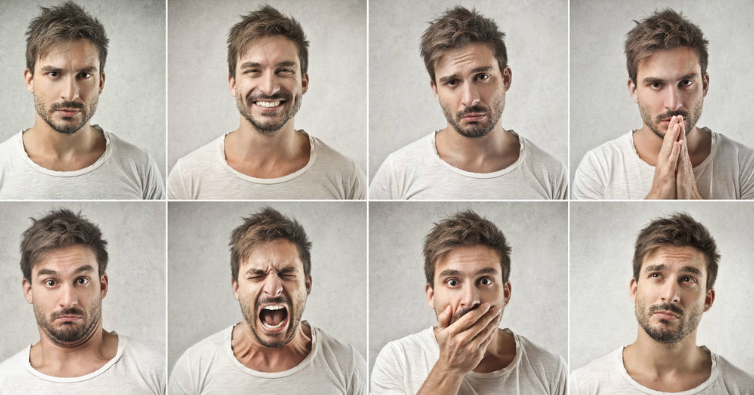

In [53]:
image = cv2.imread(image_folder_path + 'Images/faces_emotions.png')
cv2_imshow(image)

In [54]:
faces = face_detector.detectMultiScale(image)
faces

array([[224,  35,  90,  90],
       [625,  49,  91,  91],
       [ 23,  41,  92,  92],
       [420,  43,  97,  97],
       [420, 242,  97,  97],
       [ 18, 243,  98,  98],
       [229, 242,  85,  85],
       [627, 241,  91,  91]], dtype=int32)

In [55]:
test_dataset.class_indices.keys()

dict_keys(['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise'])

In [56]:
emotions = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


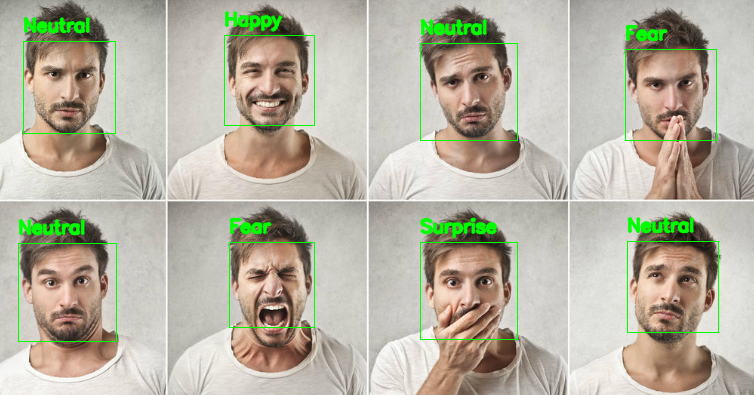

In [57]:
for (x, y, w, h) in faces:
  cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 1)
  roi = image[y:y + h, x:x + w]
  #cv2_imshow(roi)
  roi = cv2.resize(roi, (48, 48))
  #cv2_imshow(roi)
  roi = roi / 255
  roi = np.expand_dims(roi, axis = 0)
  #print(roi.shape)
  prediction = network_loaded.predict(roi)
  #print(prediction)
  cv2.putText(image, emotions[np.argmax(prediction)], (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2, cv2.LINE_AA)
cv2_imshow(image)

### Classifying Emotions - in video file

In [59]:
cap = cv2.VideoCapture(image_folder_path + 'Videos/emotion_test01.mp4')
connected, video = cap.read()
print(connected, video.shape)

True (360, 640, 3)


In [ ]:
# fourcc.org - to know more about the fourcc code, visit: https://www.fourcc.org/codecs.php
save_path = image_folder_path + 'Videos/emotion_test01_result.avi'
fourcc = cv2.VideoWriter_fourcc(*'XVID')
fps = 24    
output_video = cv2.VideoWriter(save_path, fourcc, fps, (video.shape[1], video.shape[0]))

In [ ]:
while (cv2.waitKey(1) < 0):
  connected, frame = cap.read()
  if not connected:
    break
  faces = face_detector.detectMultiScale(frame, scaleFactor=1.2, minNeighbors=5, minSize=(30,30))
  if len(faces) > 0:
    
    for (x, y, w, h) in faces:
      frame = cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
      roi = frame[y:y + h, x:x + w]
      roi = cv2.resize(roi, (48, 48))
      roi = roi / 255
      roi = np.expand_dims(roi, axis = 0)
      prediction = network_loaded.predict(roi)

      if prediction is not None:
        result = np.argmax(prediction)
        cv2.putText(frame, emotions[result], (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1, cv2.LINE_AA)
  
  cv2_imshow(frame)
  output_video.write(frame)

print('End')
output_video.release()
cv2.destroyAllWindows()